<a href="https://colab.research.google.com/github/faune667/coding-tools/blob/main/Information%20Retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ce que nous avons fait

Nettoyage et préparation des données

Nous avons importé plusieurs jeux de données (CSV, Excel), exploré leur structure, nettoyé les textes (suppression de la ponctuation, des chiffres, des mots courts, passage en minuscules) et transformé les descriptions en tokens (mots) pour préparer l’analyse.
Calcul “à la main” du TF-IDF

Pour bien comprendre le pipeline NLP, nous avons codé nous-mêmes le calcul du TF (Term Frequency), DF (Document Frequency), IDF (Inverse Document Frequency) et TF-IDF, sans utiliser scikit-learn. Cela nous a permis de construire une matrice TF-IDF où chaque ligne représente un document et chaque colonne un mot du corpus.
Modélisation et évaluation

Nous avons utilisé la matrice TF-IDF comme entrée pour un modèle de classification (SVM), puis évalué ses performances avec accuracy, precision, recall, F1-score et matrice de confusion.

Nous avons aussi visualisé la distribution des classes et les erreurs du modèle.
Optimisation par hyperparamétrage

Nous avons automatisé la recherche des meilleurs paramètres (GridSearchCV) pour le pipeline TF-IDF + SVM, ce qui a permis d’augmenter l’accuracy de 84 % à 92 % sur le jeu de test.


Axes d’amélioration pour la deuxième partie (meilleure accuracy)

Collecte de données supplémentaires

Les classes minoritaires (“bebe et puericulture”, “jeux video”, etc.) restent difficiles à prédire. Ajouter plus d’exemples pour ces catégories améliorerait la robustesse du modèle.
Feature engineering avancé

Combiner plusieurs colonnes de texte (ex : nom + description), ajouter des variables numériques ou catégorielles (prix, marque…), ou utiliser des n-grams plus larges.
Nettoyage et enrichissement du texte

Ajouter la suppression des stopwords, la lemmatisation, ou l’utilisation de techniques avancées de prétraitement pour rendre les descriptions plus informatives.
Test d’autres modèles

Essayer des modèles plus robustes (RandomForest, XGBoost, deep learning) ou des techniques d’ensemble (bagging, boosting).
Gestion du déséquilibre des classes

Utiliser des techniques de sur-échantillonnage (SMOTE), de sous-échantillonnage, ou d’ajustement des poids de classe pour mieux traiter les catégories rares.
Optimisation continue

Affiner la grille d’hyperparamètres, tester d’autres métriques d’optimisation (macro F1, recall, etc.), et automatiser la génération de rapports pour chaque essai.


In [2]:
import pandas as pd

# Lecture du fichier CSV
df = pd.read_csv('/content/tf_idf_dataset.csv')

# Affichage des premières lignes pour vérifier le chargement
print(df.head())


                                        product_name
0  xiaomi mi 9t pro smartphone 6 + 128 go redmi k...
1  huawei honor v10 (view 10) smartphone 4g (6go+...
2                        apple iphone 11 jaune 64 go
3      samsung galaxy s7 32 go argent excellent etat
4  samsung galaxy a8 (2018) sm-a530f-ds smartphon...


In [3]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Enlève la ponctuation et les chiffres
    text = re.sub(r'\b\w{1,2}\b', '', text)  # Enlève les mots de moins de 3 lettres
    return text.lower().split()


In [4]:
df['cleaned_product_name'] = df['product_name'].apply(clean_text)


In [5]:
print(df[['product_name', 'cleaned_product_name']].head())


                                        product_name  \
0  xiaomi mi 9t pro smartphone 6 + 128 go redmi k...   
1  huawei honor v10 (view 10) smartphone 4g (6go+...   
2                        apple iphone 11 jaune 64 go   
3      samsung galaxy s7 32 go argent excellent etat   
4  samsung galaxy a8 (2018) sm-a530f-ds smartphon...   

                                cleaned_product_name  
0  [xiaomi, pro, smartphone, redmi, chargeur, rap...  
1  [huawei, honor, view, smartphone, gogo, androi...  
2                             [apple, iphone, jaune]  
3         [samsung, galaxy, argent, excellent, etat]  
4  [samsung, galaxy, smafds, smartphone, double, ...  


In [6]:
# On suppose que df['cleaned_product_name'] est une liste de mots pour chaque document

tf_list = []
for tokens in df['cleaned_product_name']:
    tf_doc = {}
    total_terms = len(tokens)
    for word in tokens:
        tf_doc[word] = tf_doc.get(word, 0) + 1
    # Normalisation
    for word in tf_doc:
        tf_doc[word] /= total_terms
    tf_list.append(tf_doc)

# tf_list est une liste de dictionnaires, un par document


In [7]:
from collections import Counter

df_counter = Counter()
for tf_doc in tf_list:
    for word in tf_doc.keys():
        df_counter[word] += 1

# df_counter[word] donne le nombre de documents où le mot apparaît


In [8]:
import math

N = len(df)
idf_dict = {}
for word, doc_freq in df_counter.items():
    idf_dict[word] = math.log(N / doc_freq)


In [9]:
tfidf_list = []
for tf_doc in tf_list:
    tfidf_doc = {}
    for word, tf_value in tf_doc.items():
        tfidf_doc[word] = tf_value * idf_dict[word]
    tfidf_list.append(tfidf_doc)


In [10]:
tfidf_df = pd.DataFrame(tfidf_list).fillna(0)
print(tfidf_df.head())


    xiaomi       pro  smartphone    redmi  chargeur    rapide       mah  \
0  0.24718  0.185001    0.170164  0.24718  0.401213  0.401213  0.279145   
1  0.00000  0.000000    0.109391  0.00000  0.000000  0.000000  0.000000   
2  0.00000  0.000000    0.000000  0.00000  0.000000  0.000000  0.000000   
3  0.00000  0.000000    0.000000  0.00000  0.000000  0.000000  0.000000   
4  0.00000  0.000000    0.127623  0.00000  0.000000  0.000000  0.000000   

     flamme     rouge    huawei  ...  sideral  air  cellulaire  mini  \
0  0.401213  0.324197  0.000000  ...      0.0  0.0         0.0   0.0   
1  0.000000  0.208412  0.158902  ...      0.0  0.0         0.0   0.0   
2  0.000000  0.000000  0.000000  ...      0.0  0.0         0.0   0.0   
3  0.000000  0.000000  0.000000  ...      0.0  0.0         0.0   0.0   
4  0.000000  0.000000  0.000000  ...      0.0  0.0         0.0   0.0   

   cellular  modell  tab  yoga  smart  emcp  
0       0.0     0.0  0.0   0.0    0.0   0.0  
1       0.0     0.0  0.0

In [11]:
top_words = tfidf_df.apply(lambda row: row.nlargest(5).index.tolist(), axis=1)
print(top_words)


0                [chargeur, rapide, flamme, rouge, mah]
1                     [kirin, octa, mpmp, rouge, honor]
2                   [jaune, iphone, apple, xiaomi, pro]
3            [excellent, etat, argent, samsung, galaxy]
4                [smafds, lte, microsdxc, slot, pixels]
5                    [rom, simbleu, honor, ram, huawei]
6             [fhd, helio, arriere, etanche, blackview]
7              [reconditionne, tres, bon, iphone, etat]
8     [ultramince, dualcore, bluetooth, gsm, telephone]
9                [vert, xiaomi, redmi, pro, smartphone]
10            [orange, mpmpmp, batterie, camera, ecran]
11                     [note, vert, xiaomi, redmi, pro]
12               [pas, cher, debloque, simcamera, sans]
13                   [sony, xperia, blanc, xiaomi, pro]
14                     [wiko, black, view, xiaomi, pro]
15               [mate, verde, esmeralda, evrn, huawei]
16                 [motorola, one, action, denim, blue]
17        [bleu, blackview, pouces, smartphone, 

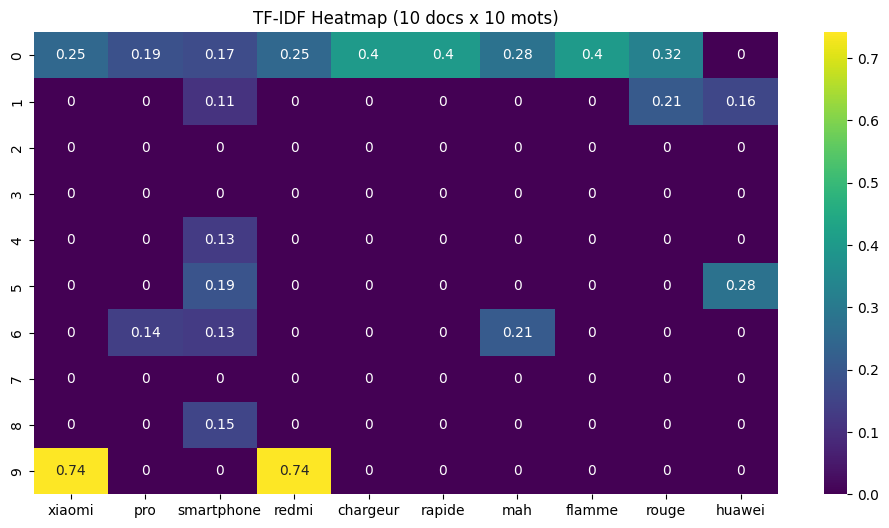

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_df.iloc[:10, :10], annot=True, cmap='viridis')
plt.title('TF-IDF Heatmap (10 docs x 10 mots)')
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving classification dataset.xlsx to classification dataset.xlsx


In [ ]:
import pandas as pd

# Lecture du fichier Excel
df = pd.read_excel('/content/classification dataset.xlsx')

# Aperçu des premières lignes et des colonnes
print(df.head())
print(df.columns)
print(df.info())
print(df.isnull().sum())


                                        product_name      real_category  \
0    - 15 % sur les croquettes pour chat perfect fit         animalerie   
1  [latest version]victsing(r) 5500 dpi souris ga...          high-tech   
2  [nouveau]atoto a6 2din android car navigation ...          high-tech   
3  [nouvelle generation] xiaomi d'origine mi band...          high-tech   
4  * seche-serviettes electrique a inertie fluide...  cuisine et maison   

          prediction  Unnamed: 3    real_category.1  
0         animalerie         NaN         animalerie  
1          high-tech         NaN          high-tech  
2          high-tech         NaN  cuisine et maison  
3          high-tech         NaN       auto et moto  
4  cuisine et maison         NaN           epicerie  
Index(['product_name', 'real_category', 'prediction', 'Unnamed: 3',
       'real_category.1'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 # 

In [ ]:
import pandas as pd

# Lecture du fichier
df = pd.read_excel('/content/classification dataset.xlsx')

# Suppression des colonnes inutiles
df = df.drop(columns=['Unnamed: 3', 'real_category.1'])

# Nettoyage du texte (exemple simple)
import re
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    text = re.sub(r'\b\w{1,2}\b', '', text)
    return text.lower().strip()

df['cleaned_product_name'] = df['product_name'].apply(clean_text)

print(df.head())


                                        product_name      real_category  \
0    - 15 % sur les croquettes pour chat perfect fit         animalerie   
1  [latest version]victsing(r) 5500 dpi souris ga...          high-tech   
2  [nouveau]atoto a6 2din android car navigation ...          high-tech   
3  [nouvelle generation] xiaomi d'origine mi band...          high-tech   
4  * seche-serviettes electrique a inertie fluide...  cuisine et maison   

          prediction                               cleaned_product_name  
0         animalerie           sur les croquettes pour chat perfect fit  
1          high-tech  latest versionvictsingr  dpi souris gamingsour...  
2          high-tech  nouveauatoto  din android car navigation stere...  
3          high-tech  nouvelle generation xiaomi dorigine  band  wri...  
4  cuisine et maison  secheserviettes electrique  inertie fluide sau...  


In [ ]:
print(df['real_category'].value_counts())
print(df['prediction'].value_counts())


real_category
cuisine et maison       205
high-tech               199
vetements               175
epicerie                172
animalerie              134
auto et moto             64
hygiene et sante         25
jeux video               13
bebe et puericulture     13
Name: count, dtype: int64
prediction
high-tech               204
cuisine et maison       198
vetements               180
epicerie                153
animalerie              121
auto et moto             60
hygiene et sante         34
bebe et puericulture     26
jeux video               24
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = df['real_category']
y_pred = df['prediction']

# Accuracy globale
print("Accuracy:", accuracy_score(y_true, y_pred))

# Rapport détaillé (precision, recall, F1-score par classe)
print(classification_report(y_true, y_pred))


Accuracy: 0.836
                      precision    recall  f1-score   support

          animalerie       0.92      0.83      0.87       134
        auto et moto       0.68      0.64      0.66        64
bebe et puericulture       0.38      0.77      0.51        13
   cuisine et maison       0.89      0.86      0.87       205
            epicerie       0.88      0.78      0.82       172
           high-tech       0.93      0.95      0.94       199
    hygiene et sante       0.47      0.64      0.54        25
          jeux video       0.00      0.00      0.00        13
           vetements       0.88      0.90      0.89       175

            accuracy                           0.84      1000
           macro avg       0.67      0.71      0.68      1000
        weighted avg       0.86      0.84      0.84      1000



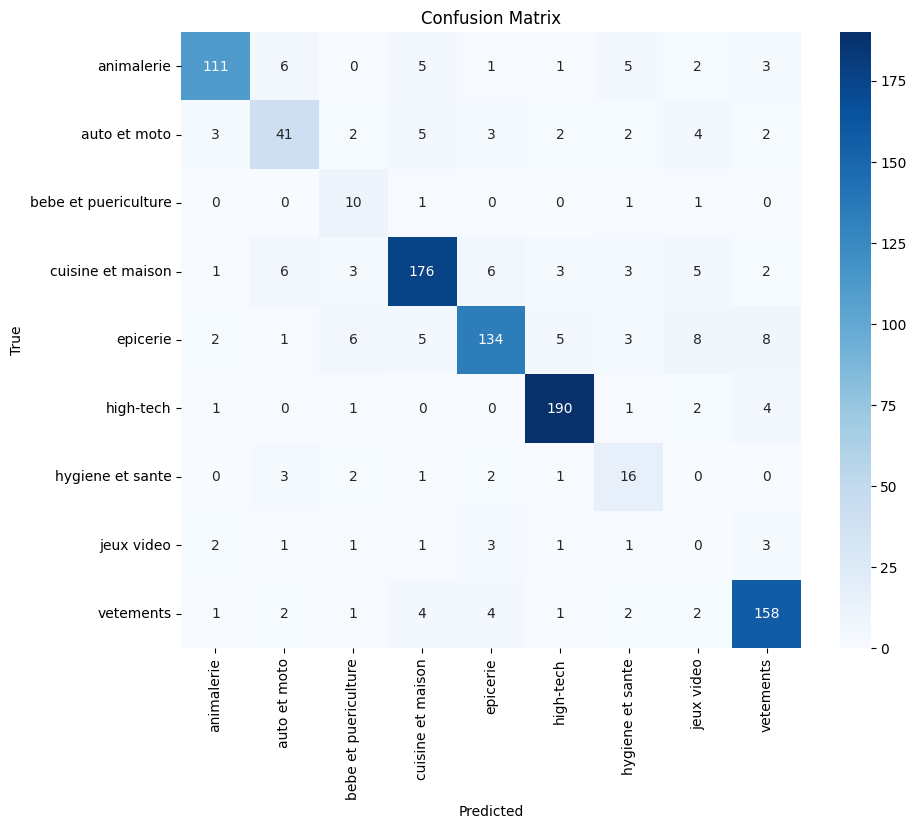

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(df['real_category'].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Séparation train/test
X = df['cleaned_product_name']
y = df['real_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline : TF-IDF + SVM
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

# Grille d’hyperparamètres à tester
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 3, 5],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'clf__C': [0.1, 1, 10]
}

# GridSearch
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

# Évaluation sur le test set
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'clf__C': 10, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Best score: 0.8388858399550001
                      precision    recall  f1-score   support

          animalerie       0.96      1.00      0.98        27
        auto et moto       1.00      0.85      0.92        13
bebe et puericulture       1.00      0.33      0.50         3
   cuisine et maison       0.88      0.90      0.89        41
            epicerie       0.94      0.85      0.89        34
           high-tech       0.95      0.95      0.95        40
    hygiene et sante       1.00      1.00      1.00         5
          jeux video       1.00      0.50      0.67         2
           vetements       0.83      0.97      0.89        35

            accuracy                           0.92       200
           macro avg       0.95      0.82      0.85       200
        weighted avg       0.92      0.92      0.91       200